In [1]:
import pandas as pd
import numpy as np
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce

import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.api as stm
import statsmodels.api as sm
from sklearn.utils.class_weight import compute_class_weight

# for survival analysis
import lifelines
from epi_utils import *
from datetime import datetime

from Bio import SeqIO, Entrez
import xml.etree.ElementTree as ET
from dateutil import parser

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETA",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

# 7H10 critical concentrations dictionary
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100}

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_WHO_catalog.csv")

drugs_lst = ['RIF', 'INH', 'EMB', 'PZA']

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed"

who_variants = pd.read_csv("../../data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

# MIC encoding from the TRUST codebook
MIC_encoding_dicts = {'RIF': {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,inf'},
                      'INH': {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,inf'},
                      'EMB': {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,inf'},
                      'PZA': {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,inf'}
                     }

RIF_label_encoding_dict = {1: '≤0.03', 2: '0.03-0.06', 3: '0.06-0.125', 4: '0.125-0.25', 5: '0.25-0.5', 6: '0.5-1', 7: '>1'}
INH_label_encoding_dict = {1: '≤0.025', 2: '0.025-0.05', 3: '0.05-0.1', 4: '0.1-0.2', 5: '>0.2'}
EMB_label_encoding_dict = {1: '≤0.6', 2: '0.6-1.25', 3: '1.25-2.5', 4: '2.5-5', 5: '>5'}
PZA_label_encoding_dict = {1: '≤25', 2: '25-50', 3: '50-75', 4: '75-100', 5: '>100'}

MIC_label_encoding_dicts = {'RIF': RIF_label_encoding_dict, 'INH': INH_label_encoding_dict, 'EMB': EMB_label_encoding_dict, 'PZA': PZA_label_encoding_dict}

# Analysis of Contaminants in Samples with Kraken Unclassified > 20%

In [2]:
df_TRUST_patients = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")

In [3]:
df_TRUST = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")

kraken_unclassified_samples = np.sort(df_TRUST.query("Kraken_Unclassified_Percent > 20").SampleID.values)
len(kraken_unclassified_samples)

29

In [5]:
vcf_paths = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None)
len(vcf_paths)

733

In [6]:
len(vcf_paths) + len(kraken_unclassified_samples) == len(df_TRUST)

True

In [9]:
vcf_samples = [os.path.basename(fName).split('.')[0] for fName in vcf_paths[0].values]

In [11]:
set(vcf_samples).symmetric_difference(df_TRUST.query("Kraken_Unclassified_Percent <= 20").SampleID)

set()

In [13]:
set(vcf_samples).intersection(kraken_unclassified_samples)

set()

In [20]:
df_TRUST.dropna(subset='Freschi2020').query("Freschi2020.str.contains(',')")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_10x,Perc_Sites_20x,F2,Coll2014,Freschi2020,Lineage,Culture_Mixed_Infection,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
76,T0252,MFS-168,1.35,382.326083,392.0,99.426888,99.283786,0.477297,"4.1.1.3,2.2.1.1","4.1.i1.2.1,2.2.1.1.1","2,4",1,4.1.i1.2.1,2.2.1.1.1,"beijing,xtype","lin2.2.1,pacific_RD150",NaN
127,T0267,MFS-270,0.57,298.796325,306.0,99.143381,98.926881,0.245979,2.2.1.1,"2.2.1.1.1,4.2.1.2.1.1.i1","2,4",1,2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN
175,T0305,MFS-313,0.91,322.862748,330.0,99.098567,98.946783,0.436810,"4.3.2.1,2.2.1.1","2.2.1.1.1,4.2.1.2.1.1.i1","2,4",1,2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam","lin2.2.1,pacific_RD150",4.3/LAM
179,T0311,MFS-317,0.69,379.240440,388.0,99.134677,98.974143,0.369685,"4.3.2.1,2.2.1.1","2.2.1.1.1,4.2.1.2.1.1.i1","2,4",1,2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam","lin2.2.1,pacific_RD150",4.3/LAM
200,T0010,MFS-336,0.34,337.337377,337.0,99.275648,99.130982,0.458952,"4.1.1.1,2.2.1.1","4.1.i1.2.1,2.2.1.1.1","2,4",1,4.1.i1.2.1,2.2.1.1.1,"beijing,xtype,westafrican1","lin2.2.1,pacific_RD150",NaN
216,T0072,MFS-350,0.42,344.440217,340.0,99.473584,99.345103,0.408194,"4.1.2.1,4.8","4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4,1,4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem
218,T0087,MFS-353,0.36,419.230392,404.0,99.482855,99.374435,0.415768,"4.1.2.1,4.8","4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1",4,1,4.2.1.1.1.1.1.1.i1,4.1.i1.1.1.1,"haarlem,canetti",NaN,4.1.2/Haarlem
356,T0391,MFS-483,0.40,265.043600,271.0,99.226595,99.070527,0.474464,"4.1.1.3,2.2.1.1","4.1.i1.2.1,2.2.1.1.1","2,4",1,4.1.i1.2.1,2.2.1.1.1,"beijing,xtype","lin2.2.1,pacific_RD150",NaN
515,T0204,MFS-631,0.59,269.194783,271.0,99.395561,99.200096,0.314259,"2.2.1,3.1.1","2.2.1.1.1,3.1.1.i1","2,3",1,2.2.1.1.1,3.1.1.i1,"beijing,east_african_indian,mungi",lin2.2.1,NaN
594,T0444,MFS-707,0.49,454.523204,467.0,99.149071,99.043371,0.313857,"4.3.4.2.1,4.1.1.1","4.1.i1.2,4.2.1.2.1.1.i3.1",4,1,4.1.i1.2,4.2.1.2.1.1.i3.1,"lam,xtype,westafrican1",NaN,4.3/LAM


In [12]:
df_report = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/2024-11-13_report.v10.xlsx", sheet_name=None)['summary']

In [18]:
df_report.SampleID.nunique(), df_TRUST.query("SampleID in @df_report.SampleID").SampleID.nunique()

(188, 163)

In [5]:
kraken_unclassified_samples

array(['MFS-179', 'MFS-183', 'MFS-304', 'MFS-422', 'MFS-423', 'MFS-425',
       'MFS-451', 'MFS-453', 'MFS-477', 'MFS-490', 'MFS-491', 'MFS-492',
       'MFS-493', 'MFS-494', 'MFS-495', 'MFS-496', 'MFS-497', 'MFS-498',
       'MFS-499', 'MFS-500', 'MFS-501', 'MFS-502', 'MFS-503', 'MFS-504',
       'MFS-505', 'MFS-506', 'MFS-507', 'MFS-508', 'MFS-78'], dtype=object)

In [ ]:
bracken -d "/n/data1/hms/dbmi/farhat/mm774/References/Kraken2_DB_Dir/Kraken2_DB" -i /n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/MFS-179/MFS-179/kraken/kraken_report_standard_DB -o /n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/MFS-179/MFS-179/kraken/bracken_report -r 150 -l G1 -t 77643

In [61]:
df_TRUST_patients['status'].unique()

array([nan, 'finished', 'in progress', 'failed'], dtype=object)

In [65]:
failed_by_borstel = df_TRUST_patients.query("status=='failed'").SampleID.values
len(failed_by_borstel)

16

In [72]:
og_missing_samples = df_TRUST_patients.loc[pd.isnull(df_TRUST_patients['Lineage'])].SampleID.values
len(og_missing_samples)

54

In [73]:
kraken_contam_og_missing_samples = list(set(og_missing_samples).intersection(kraken_unclassified_samples))
len(kraken_contam_og_missing_samples)

10

In [83]:
contamination_update.query("MFS_ID in @og_missing_samples & MFS_ID not in @kraken_unclassified_samples").shape

(44, 6)

In [85]:
contamination_update.query("MFS_ID in @og_missing_samples & MFS_ID not in @kraken_unclassified_samples").Class.value_counts()

Class
Contam         22
Outstanding    20
Error           1
Seq fail        1
Name: count, dtype: int64

In [77]:
contamination_update.query("MFS_ID in @og_missing_samples").shape

(44, 6)

In [53]:
missing_samples = list(set(kraken_unclassified_samples) - set(df_TRUST_patients["SampleID"]))
len(missing_samples)

19

In [51]:
df_report = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/2023-09-01_report_Farhat.v09.xlsx", sheet_name=None)

In [55]:
df_report['summary'].query("SampleID in @missing_samples").shape

(19, 11)

In [56]:
df_report['summary'].query("SampleID in @missing_samples")

,SampleID,original ID,shipment,status,comment,SampleLib,"phylogenetic classification (Coll et al., 2014)",quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped
415,MFS-507,T-7,3rd,failed,Baym mit +5 Zyklen,MFS-507_lib59695,4.3.2.1 LAM,1.0,52.12,0.99,0.4505
416,MFS-505,T-5,3rd,failed,Baym mit +5 Zyklen,MFS-505_lib59693,2.2.1.1 Beijing Pacific RD150,2.0,35.10,0.96,0.2683
418,MFS-492,P-T- 1,3rd,failed,Baym mit +5 Zyklen,MFS-492_lib59680,2.2.1.1 Beijing,4.0,17.81,0.88,0.1026
420,MFS-506,T-6,3rd,failed,Baym mit +5 Zyklen,MFS-506_lib59694,2.2.1 Beijing,4.0,13.24,0.75,0.0965
422,MFS-500,C-8,3rd,failed,Baym mit +5 Zyklen,MFS-500_lib59688,2.2.1.1 Beijing Pacific RD150,4.0,9.19,0.49,0.0606
423,MFS-494,C-2,3rd,failed,Baym mit +5 Zyklen,MFS-494_lib59682,-,4.0,8.85,0.00,0.0024
425,MFS-495,C-3,3rd,failed,Baym mit +5 Zyklen,MFS-495_lib59683,4.4 Euro-American,4.0,7.95,0.00,0.0033
426,MFS-504,T-4,3rd,failed,Baym mit +5 Zyklen,MFS-504_lib59692,4.3.2.1 LAM,4.0,6.56,0.24,0.0644
427,MFS-499,C-7,3rd,failed,Baym mit +5 Zyklen,MFS-499_lib59687,4.3.2 LAM Asian/Africa 1,4.0,5.72,0.19,0.0337
429,MFS-508,T-8,3rd,failed,Baym mit +5 Zyklen,MFS-508_lib59696,2.2.1.1 Beijing Pacific RD150,4.0,4.96,0.07,0.0331


In [22]:
df_TRUST.query("SampleID=='MFS-270'")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_10x,Perc_Sites_20x,F2,Coll2014,Freschi2020,Lineage,Culture_Mixed_Infection,Freschi_Lineage_1,Freschi_Lineage_2,Lipworth2019,Shitikov2017,Stucki2016
127,T0267,MFS-270,0.57,298.796325,306.0,99.143381,98.926881,0.245979,2.2.1.1,"2.2.1.1.1,4.2.1.2.1.1.i1","2,4",1,2.2.1.1.1,4.2.1.2.1.1.i1,"beijing,lam,mungi","lin2.2.1,pacific_RD150",NaN


In [40]:
os.listdir("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports")

['2023-01-24_report_Farhat.v09.xlsx',
 '2023-09-01_report_Farhat.v09.xlsx',
 '2024-05-27_report.v10.xlsx',
 '2024-06-25_report.v10.xlsx',
 '2024-11-13_report.v10.xlsx']

In [37]:
kraken_unclassified_samples

array(['MFS-179', 'MFS-183', 'MFS-304', 'MFS-422', 'MFS-423', 'MFS-425',
       'MFS-451', 'MFS-453', 'MFS-477', 'MFS-490', 'MFS-491', 'MFS-492',
       'MFS-493', 'MFS-494', 'MFS-495', 'MFS-496', 'MFS-497', 'MFS-498',
       'MFS-499', 'MFS-500', 'MFS-501', 'MFS-502', 'MFS-503', 'MFS-504',
       'MFS-505', 'MFS-506', 'MFS-507', 'MFS-508', 'MFS-78'], dtype=object)

In [15]:
contamination_update = pd.read_excel("Contamination_Update_140124.xlsx", sheet_name=None)['Sheet1']

In [11]:
no_FQ = df_TRUST_patients.query("SampleID not in @df_TRUST.SampleID").SampleID.values

len(no_FQ)

44

In [66]:
contamination_update.query("MFS_ID in @failed_by_borstel")

,MFS_ID,Isolate,Class,Status,MFS_new,Isolate_new
9,MFS-376,S0165-05,Error,Labelling error sample doesn’t exist,NaN,NaN
10,MFS-378,S0198-06,Contam,Cultured and sequenced alternate isolate,MFS-113,S0198-07
11,MFS-379,S0199-05,Contam,Cultured and sequenced alternate isolate,MFS-114,S0199-06
12,MFS-380,S0211-09,Contam,Cultured and sequenced alternate isolate,MFS-121,S0211-08
13,MFS-384,S0272-06,Contam,Cultured and sequenced alternate isolate,MFS-279,S0272-09
14,MFS-386,S0282-01,Contam,Cultured and sequenced alternate isolate,MFS-323,S0282-02
23,MFS-352,S0073-01,Seq fail,Recultured and sequenced,MFS-557,S0073-01


In [71]:
df_TRUST_patients.query("SampleID=='MFS-557'")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
279,T0073,S0073-01,MFS-557,1.0,MFS-557_lib64397,NaN,NaN,1.0,259.8,1.0,...,0.149688,NaN,0.875,0.95,0,181,0.010704,3.1.1,3.1.1.i1,3


In [19]:
borstel_contaminated = contamination_update.query("Class=='Contam'")['MFS_ID'].values
len(borstel_contaminated)

22

(44, 6)

In [22]:
contamination_update.query("Class=='Outstanding'").shape

(20, 6)

In [26]:
contamination_update.dropna(subset='MFS_ID').MFS_ID.nunique()

44

In [29]:
set(no_FQ).symmetric_difference(contamination_update.dropna(subset='MFS_ID').MFS_ID)

set()

In [31]:
contamination_update.query("MFS_ID in @kraken_unclassified_samples")

,MFS_ID,Isolate,Class,Status,MFS_new,Isolate_new


In [27]:
contamination_update.dropna(subset='MFS_ID')

,MFS_ID,Isolate,Class,Status,MFS_new,Isolate_new
0,MFS-562,S0081-01,Contam,Reculturing,NaN,NaN
1,MFS-568,S0099-06,Contam,Reculturing,NaN,NaN
2,MFS-653,S0272-m5,Contam,Reculturing,NaN,NaN
3,MFS-712,S0450-01,Contam,Reculturing,NaN,NaN
4,MFS-749,S0157-01,Contam,Reculturing,NaN,NaN
5,MFS-775,S0382-01,Contam,Reculturing,NaN,NaN
6,MFS-810,S0428-01,Contam,Reculturing,NaN,NaN
7,MFS-827,S0447-04,Contam,Reculturing,NaN,NaN
8,MFS-785,S0402-04,Contam,Reculturing,NaN,NaN
9,MFS-376,S0165-05,Error,Labelling error sample doesn’t exist,NaN,NaN


In [13]:
pd.DataFrame({'A': kraken_unclassified_samples, 'B': kraken_unclassified_samples, 'C': 0}).iloc[:, :].to_csv("/home/sak0914/Mtb_Megapipe/TRUST_samples.tsv", index=False, sep='\t', header=None)

In [3]:
kraken_unclassified_samples

array(['MFS-179', 'MFS-183', 'MFS-304', 'MFS-422', 'MFS-423', 'MFS-425',
       'MFS-451', 'MFS-453', 'MFS-477', 'MFS-490', 'MFS-491', 'MFS-492',
       'MFS-493', 'MFS-494', 'MFS-495', 'MFS-496', 'MFS-497', 'MFS-498',
       'MFS-499', 'MFS-500', 'MFS-501', 'MFS-502', 'MFS-503', 'MFS-504',
       'MFS-505', 'MFS-506', 'MFS-507', 'MFS-508', 'MFS-78'], dtype=object)

In [295]:
df_kraken_contaminants = pd.DataFrame(columns = ['SampleID', 'Custom_DB_MTBC_percent', 'non_MTBC_mycobacteria', 'unclassified_percent', 'MTBC_percent', 'NTM_percent', 'NTM_mycobacteria_percent', 'Human_percent', 'Most_Common_Genus', 'Most_Common_Genus_percent', 'Second_Most_Common_Genus', 'Second_Most_Common_Genus_percent'])#, 'Most_Common_Species'])

for i, sample in enumerate(kraken_unclassified_samples):

    fName = f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report_standard_DB"

    if os.path.isfile(fName):

        df_kraken_custom_DB = pd.read_csv(f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report", sep='\t', header=None)
        df_kraken_custom_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']

        kraken_custom_DB_MTBC_percent = 100 - df_kraken_custom_DB.query("TaxLevel=='U'")['Percent'].values[0]

        df_kraken_standard_DB = pd.read_csv(fName, sep='\t', header=None)
        df_kraken_standard_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']

        non_MTBC_mycobacteria = df_kraken_standard_DB.query("TaxID in @mycobacterium_child_taxids & TaxID not in @MTBC_child_taxids & TaxLevel == 'S'")['Percent'].sum()

        unclassified_percent = df_kraken_standard_DB.query("TaxLevel=='U'")['Percent'].values[0]

        MTBC_percent = df_kraken_standard_DB.query("TaxID==77643")['Percent'].values[0]
        
        try:
            # M. leprosy is in the genus Mycobacterium. NTM = all Mycobacteria that are not MTBC or M. leprae BUT some NTMs have been split into other genera, so also need to include those
            M_leprae_percent = df_kraken_standard_DB.query("TaxName.str.contains('leprae') & TaxLevel=='S'")['Percent'].sum()
        except:
            M_leprae_percent = 0

        human_percent = df_kraken_standard_DB.query("TaxName.str.contains('Homo sapiens')")['Percent'].values[0]

        try:
            # this is a G1 level
            unclassified_mycobacterium_percent = df_kraken_standard_DB.query("TaxName.str.contains('unclassified Mycobacterium')")['Percent'].values[0]
        except:
            unclassified_mycobacterium_percent = 0

        # Mycobacterium is the genus level. MTBC, M. avium complex, etc. are all G1 level
        mycobacterium_percent = df_kraken_standard_DB.query("TaxID==1763")['Percent'].values[0]

        # NTMs were recently split into some other genera: Mycobacteroides, Mycolicibacter, Mycolicibacterium and Mycolicibacillus
        other_NTM_genera_percent = df_kraken_standard_DB.query("TaxLevel=='G' & TaxName.str.contains('|'.join(['Mycobacteroides', 'Mycolicibacter', 'Mycolicibacterium', 'Mycolicibacillus']))")['Percent'].sum()

        # NTMs will be full mycobacterium - MTBC - M. leprae - unclassified mycobacterium + other NTM genera
        # full mycobacterium = G
        # MTBC, unclassified mycobacterium = G1
        # M. leprae is just a G and S
        NTM_mycobacteria_percent = mycobacterium_percent - MTBC_percent - M_leprae_percent - unclassified_mycobacterium_percent
        NTM_percent = mycobacterium_percent - MTBC_percent - M_leprae_percent - unclassified_mycobacterium_percent + other_NTM_genera_percent

        # get the most common contaminating genus and species. Remove spaces for ease
        most_common_genus = df_kraken_standard_DB.query("TaxLevel=='G'").sort_values('Percent', ascending=False)['TaxName'].str.lstrip().values[0]
        second_most_common_genus = df_kraken_standard_DB.query("TaxLevel=='G'").sort_values('Percent', ascending=False)['TaxName'].str.lstrip().values[1]
        # most_common_species = df_kraken_standard_DB.query("TaxLevel=='S'").sort_values('Percent', ascending=False)['TaxName'].str.lstrip().values[0]

        most_common_genus_percent = df_kraken_standard_DB.query("TaxLevel=='G'")['Percent'].values.max()
        second_most_common_genus_percent = df_kraken_standard_DB.query("TaxLevel=='G'").sort_values('Percent', ascending=False)['Percent'].values[1]
        
        df_kraken_contaminants.loc[i, :] = [sample, kraken_custom_DB_MTBC_percent, non_MTBC_mycobacteria, unclassified_percent, MTBC_percent, NTM_percent, NTM_mycobacteria_percent, human_percent, most_common_genus, most_common_genus_percent, second_most_common_genus, second_most_common_genus_percent]#, most_common_species]

    else:
        print(sample)


df_kraken_contaminants[['SampleID', 'unclassified_percent', 'MTBC_percent', 'NTM_percent', 'Human_percent', 'Most_Common_Genus', 'Most_Common_Genus_percent', 'Second_Most_Common_Genus', 'Second_Most_Common_Genus_percent']].sort_values("SampleID").to_csv("Kraken_Contamination_analysis.csv", index=False)
# df_kraken_contaminants['Sum_Percent'] = df_kraken_contaminants[df_kraken_contaminants.columns[df_kraken_contaminants.columns.str.contains('percent')]].sum(axis=1).values

<Axes: xlabel='NTM_percent', ylabel='Custom_DB_MTBC_percent'>

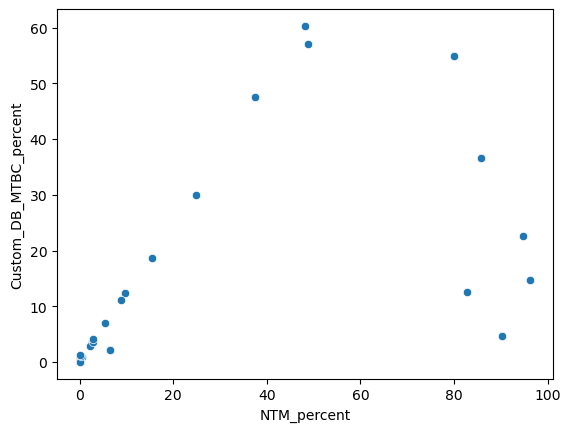

In [290]:
sns.scatterplot(data=df_kraken_contaminants,
                x='NTM_percent',
                y='Custom_DB_MTBC_percent'
               )

In [297]:
df_kraken_contaminants.query("Custom_DB_MTBC_percent < NTM_percent")

,SampleID,Custom_DB_MTBC_percent,non_MTBC_mycobacteria,unclassified_percent,MTBC_percent,NTM_percent,NTM_mycobacteria_percent,Human_percent,Most_Common_Genus,Most_Common_Genus_percent,Second_Most_Common_Genus,Second_Most_Common_Genus_percent
0,MFS-179,4.61,2.53,7.33,0.05,90.22,2.79,0.44,Mycolicibacterium,87.19,Mycobacterium,3.3
1,MFS-183,54.94,33.78,6.41,9.93,80.02,78.74,0.66,Mycobacterium,89.63,Mycolicibacterium,1.14
3,MFS-422,22.65,81.96,1.13,2.59,94.74,94.4,0.31,Mycobacterium,97.35,Homo,0.31
5,MFS-425,14.77,90.17,1.29,0.71,96.32,95.94,0.31,Mycobacterium,97.03,Homo,0.31
6,MFS-451,12.55,67.85,11.37,0.6,82.68,80.29,0.32,Mycobacterium,82.71,Mycolicibacterium,2.14
8,MFS-477,2.15,1.61,52.08,0.2,6.44,2.26,0.3,Gordonia,19.54,Mycolicibacterium,3.63
28,MFS-78,36.58,57.83,6.71,5.63,85.68,84.96,0.28,Mycobacterium,91.09,Mycolicibacterium,0.64


In [296]:
df_kraken_contaminants.query("NTM_percent > 70")

,SampleID,Custom_DB_MTBC_percent,non_MTBC_mycobacteria,unclassified_percent,MTBC_percent,NTM_percent,NTM_mycobacteria_percent,Human_percent,Most_Common_Genus,Most_Common_Genus_percent,Second_Most_Common_Genus,Second_Most_Common_Genus_percent
0,MFS-179,4.61,2.53,7.33,0.05,90.22,2.79,0.44,Mycolicibacterium,87.19,Mycobacterium,3.3
1,MFS-183,54.94,33.78,6.41,9.93,80.02,78.74,0.66,Mycobacterium,89.63,Mycolicibacterium,1.14
3,MFS-422,22.65,81.96,1.13,2.59,94.74,94.4,0.31,Mycobacterium,97.35,Homo,0.31
5,MFS-425,14.77,90.17,1.29,0.71,96.32,95.94,0.31,Mycobacterium,97.03,Homo,0.31
6,MFS-451,12.55,67.85,11.37,0.6,82.68,80.29,0.32,Mycobacterium,82.71,Mycolicibacterium,2.14
28,MFS-78,36.58,57.83,6.71,5.63,85.68,84.96,0.28,Mycobacterium,91.09,Mycolicibacterium,0.64


In [283]:
df_kraken_standard_DB.query("TaxName.str.contains('unclassified Mycobacterium')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


In [277]:
df_kraken_standard_DB.query("TaxID==1763")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
9,91.09,5465215,1506977,G,1763,Mycobacterium


In [285]:
df_kraken_standard_DB.query("TaxID in @mycobacterium_child_taxids & TaxLevel != 'G'")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
10,55.54,3331901,138176,G1,120793,Mycobacterium avium complex ...
11,37.99,2279317,0,S,339268,Mycobacterium colombiense
12,37.99,2279317,2279317,S1,1041522,Mycobacterium colombiens...
13,10.40,623690,623690,S,560555,Mycobacterium mantenii
14,2.21,132705,132705,S,701042,Mycobacterium marseillense
...,...,...,...,...,...,...
225,0.00,42,42,S1,1124626,Mycobacterium ulcerans sub...
226,0.00,105,0,S,261524,Mycobacterium liflandii
227,0.00,105,105,S1,459424,Mycobacterium liflandii 12...
228,0.00,25,0,S,265949,Mycobacterium pseudoshottsii


In [280]:
df_kraken_standard_DB.query("TaxID in @mycobacterium_child_taxids & TaxLevel=='G1'")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
10,55.54,3331901,138176,G1,120793,Mycobacterium avium complex ...
31,5.63,337931,165744,G1,77643,Mycobacterium tuberculosis c...
179,2.38,143037,8089,G1,2249310,Mycobacterium simiae complex
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


In [278]:
df_kraken_standard_DB.query("TaxName.str.contains('unclassified Mycobacterium')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


In [261]:
df_kraken_contaminants.sort_values("MTBC_percent", ascending=False).head(5)

,SampleID,Custom_DB_MTBC_percent,non_MTBC_mycobacteria,unclassified_percent,MTBC_percent,NTM_percent,Human_percent,Most_Common_Genus,Most_Common_Genus_percent,Second_Most_Common_Genus,Second_Most_Common_Genus_percent
4,MFS-423,60.32,0.44,2.11,11.94,48.12,0.21,Mycobacterium,60.1,Propionibacterium,36.59
1,MFS-183,54.94,33.78,6.41,9.93,80.02,0.66,Mycobacterium,89.63,Mycolicibacterium,1.14
2,MFS-304,47.5,0.42,1.68,9.72,37.57,0.37,Staphylococcus,50.24,Mycobacterium,47.34
26,MFS-507,56.99,0.44,1.89,8.11,48.84,35.22,Mycobacterium,56.99,Homo,35.22
28,MFS-78,36.58,57.83,6.71,5.63,85.68,0.28,Mycobacterium,91.09,Mycolicibacterium,0.64


In [262]:
df_kraken_contaminants['MTBC_NTM_sum_percent'] = df_kraken_contaminants['MTBC_percent'] + df_kraken_contaminants['NTM_percent']

In [263]:
df_kraken_contaminants.query("Most_Common_Genus=='Mycobacterium'")[['SampleID', 'Custom_DB_MTBC_percent', 'non_MTBC_mycobacteria', 'MTBC_percent', 'NTM_percent', 'MTBC_NTM_sum_percent', 'Most_Common_Genus', 'Most_Common_Genus_percent']]

,SampleID,Custom_DB_MTBC_percent,non_MTBC_mycobacteria,MTBC_percent,NTM_percent,MTBC_NTM_sum_percent,Most_Common_Genus,Most_Common_Genus_percent
1,MFS-183,54.94,33.78,9.93,80.02,89.95,Mycobacterium,89.63
3,MFS-422,22.65,81.96,2.59,94.74,97.33,Mycobacterium,97.35
4,MFS-423,60.32,0.44,11.94,48.12,60.06,Mycobacterium,60.1
5,MFS-425,14.77,90.17,0.71,96.32,97.03,Mycobacterium,97.03
6,MFS-451,12.55,67.85,0.6,82.68,83.28,Mycobacterium,82.71
26,MFS-507,56.99,0.44,8.11,48.84,56.95,Mycobacterium,56.99
28,MFS-78,36.58,57.83,5.63,85.68,91.31,Mycobacterium,91.09


In [247]:
sample = 'MFS-422'
fName = f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report_standard_DB"
df_kraken_standard_DB = pd.read_csv(fName, sep='\t', header=None)
df_kraken_standard_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']

df_kraken_custom_DB = pd.read_csv(f"{genomic_data_dir}/{sample}/{sample}/kraken/kraken_report", sep='\t', header=None)
df_kraken_custom_DB.columns = ['Percent', 'Cumul_Count', 'Count', 'TaxLevel', 'TaxID', 'TaxName']

In [248]:
df_kraken_standard_DB.query("TaxID in @child_taxids").TaxLevel.unique()

array(['G1', 'S', 'S1', 'S2', 'S3'], dtype=object)

In [249]:
df_kraken_standard_DB.query("TaxID in @MTBC_child_taxids & TaxLevel != 'G1'")['Percent'].sum()

1.56

In [251]:
df_kraken_standard_DB.query("TaxID in @mycobacterium_child_taxids & TaxLevel != 'G' & TaxID not in @MTBC_child_taxids")['Percent'].sum()

184.34000000000003

In [253]:
df_kraken_standard_DB.query("TaxID in @mycobacterium_child_taxids & TaxLevel != 'G' & TaxID not in @MTBC_child_taxids").TaxLevel.unique()

array(['G1', 'S', 'S1', 'S2'], dtype=object)

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
11,80.68,4090732,3166272,S,1764,Mycobacterium avium
19,0.24,12231,12231,S,64667,Mycobacterium lepraemurium
20,0.20,10009,8526,S,1767,Mycobacterium intracellulare
27,0.03,1681,1681,S,560555,Mycobacterium mantenii
28,0.02,1169,0,S,339268,Mycobacterium colombiense
30,0.02,978,978,S,1138383,Mycobacterium paraintracel...
31,0.02,941,941,S,701042,Mycobacterium marseillense
32,0.01,439,439,S,222805,Mycobacterium chimaera
176,0.36,18281,18281,S,44010,Mycobacterium conspicuum
178,0.03,1627,1627,S,2675523,Mycobacterium sp. DL440


In [230]:
# def get_child_taxids(parent_taxid):
#     Entrez.email = "skulkarni@g.harvard.edu"  # Replace with your email

#     # Search for child taxids
#     max_results = 10000
    
#     search_handle = Entrez.esearch(db="taxonomy", term=f"txid{parent_taxid}[Subtree]", retmax=max_results)
#     search_results = Entrez.read(search_handle)
#     search_handle.close()

#     # Fetch details for the found taxids
#     id_list = search_results["IdList"]
#     if not id_list:
#         return []

#     fetch_handle = Entrez.efetch(db="taxonomy", id=",".join(id_list), retmode="xml")
#     fetch_results = Entrez.read(fetch_handle)
#     fetch_handle.close()

#     # Extract the taxids
#     child_taxids = [taxon["TaxId"] for taxon in fetch_results]

#     if len(child_taxids) == max_results:
#         raise ValueError(f"Please raise the max_results variable. {max_results} results were found!")

#     return np.array(child_taxids).astype(int)

# Example usage
parent_taxid = 77643
MTBC_child_taxids = get_child_taxids(parent_taxid)
# print(f"{len(child_taxids)} taxids of {parent_taxid}")

parent_taxid = 1763
mycobacterium_child_taxids = get_child_taxids(parent_taxid)

In [234]:
len(MTBC_child_taxids), len(mycobacterium_child_taxids)

(3061, 6670)

In [184]:
df_kraken_standard_DB.query("TaxName.str.contains('Mycobacterium') & TaxLevel=='G1'")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
10,55.54,3331901,138176,G1,120793,Mycobacterium avium complex ...
31,5.63,337931,165744,G1,77643,Mycobacterium tuberculosis c...
179,2.38,143037,8089,G1,2249310,Mycobacterium simiae complex
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


In [185]:
df_kraken_standard_DB.query("TaxName.str.contains('unclassified Mycobacterium')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


In [181]:
df_kraken_standard_DB.query("TaxLevel=='S'")['Percent'].sum()

61.71000000000001

In [156]:
df_kraken_custom_DB.query("TaxLevel=='U'")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
0,63.42,3804670,3804670,U,0,unclassified


In [158]:
df_kraken_custom_DB

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
0,63.42,3804670,3804670,U,0,unclassified
1,36.58,2194920,0,R,1,root
2,36.58,2194920,0,R1,131567,cellular organisms
3,36.58,2194920,0,D,2,Bacteria
4,36.58,2194920,0,D1,1783272,Terrabacteria group
5,36.58,2194920,0,P,201174,Actinomycetota
6,36.58,2194920,0,C,1760,Actinomycetes
7,36.58,2194920,0,O,85007,Mycobacteriales
8,36.58,2194920,0,F,1762,Mycobacteriaceae
9,36.58,2194920,0,G,1763,Mycobacterium


In [163]:
df_kraken_contaminants.query("SampleID=='MFS-78'")#.sort_values("unclassified_percent")

,SampleID,Custom_DB_MTBC_percent,unclassified_percent,MTBC_percent,NTM_percent,Human_percent,Most_Common_Genus,Most_Common_Genus_percent,Second_Most_Common_Genus,Second_Most_Common_Genus_percent
28,MFS-78,36.58,6.71,5.63,85.68,0.28,Mycobacterium,91.09,Mycolicibacterium,0.64


In [175]:
df_kraken_contaminants[['SampleID', 'Custom_DB_MTBC_percent', 'MTBC_percent']]

,SampleID,Custom_DB_MTBC_percent,MTBC_percent
0,MFS-179,4.61,0.05
1,MFS-183,54.94,9.93
2,MFS-304,47.5,9.72
3,MFS-422,22.65,2.59
4,MFS-423,60.32,11.94
5,MFS-425,14.77,0.71
6,MFS-451,12.55,0.6
7,MFS-453,3.49,0.39
8,MFS-477,2.15,0.2
9,MFS-490,0.75,0.06


<Axes: xlabel='MTBC_percent', ylabel='Custom_DB_MTBC_percent'>

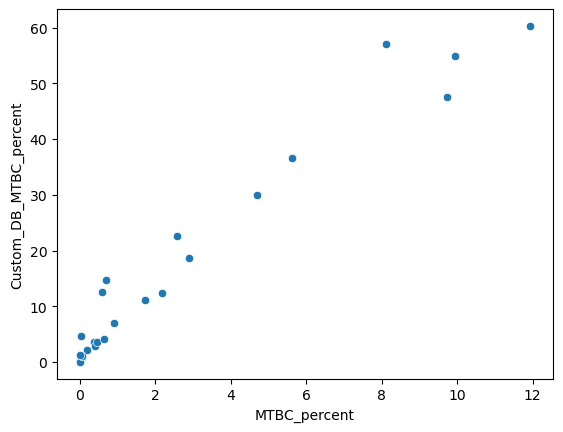

In [173]:
sns.scatterplot(data=df_kraken_contaminants,
                x='MTBC_percent',
                y='Custom_DB_MTBC_percent'
               )

In [266]:
st.spearmanr(df_kraken_contaminants['MTBC_percent'], df_kraken_contaminants['Custom_DB_MTBC_percent'])

SignificanceResult(statistic=0.9552144674515218, pvalue=8.359773985747886e-16)

In [265]:
st.pearsonr(df_kraken_contaminants['MTBC_percent'], df_kraken_contaminants['Custom_DB_MTBC_percent'])

PearsonRResult(statistic=0.9774808950585164, pvalue=8.879537894008935e-20)

In [172]:
df_trust_patients.query("SampleID=='MFS-78'")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
46,T0157,157-01,MFS-78,1.0,MFS-78_lib47065,NaN,NaN,3.0,147.41,0.7,...,1.237429,3.0,0.918033,0.881356,4,179,NaN,NaN,NaN,NaN


In [162]:
df_kraken_standard_DB.query("TaxName.str.contains('Mycobacterium tuberculosis complex')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
31,5.63,337931,165744,G1,77643,Mycobacterium tuberculosis c...


In [166]:
df_kraken_standard_DB.query("TaxLevel=='G' & TaxName.str.contains('|'.join(['Mycobacteroides', 'Mycolicibacter', 'Mycolicibacterium', 'Mycolicibacillus']))")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
230,0.64,38316,3256,G,1866885,Mycolicibacterium
281,0.05,3298,56,G,1073531,Mycolicibacter
286,0.03,1624,205,G,670516,Mycobacteroides
297,0.00,201,0,G,2126281,Mycolicibacillus


In [167]:
df_kraken_standard_DB.query("TaxLevel=='G' & TaxName.str.contains('Mycobacterium')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
9,91.09,5465215,1506977,G,1763,Mycobacterium


In [170]:
df_kraken_standard_DB.query("TaxLevel=='S' & TaxName.str.contains('Mycobacterium')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
11,37.99,2279317,0,S,339268,Mycobacterium colombiense
13,10.40,623690,623690,S,560555,Mycobacterium mantenii
14,2.21,132705,132705,S,701042,Mycobacterium marseillense
15,1.41,84666,57179,S,1764,Mycobacterium avium
21,0.55,32768,17245,S,1767,Mycobacterium intracellulare
28,0.48,28951,28951,S,222805,Mycobacterium chimaera
29,0.12,7236,7236,S,64667,Mycobacterium lepraemurium
30,0.07,4392,4392,S,1138383,Mycobacterium paraintracel...
32,2.68,160640,137413,S,1773,Mycobacterium tuberculosis
173,0.19,11547,3830,S,78331,Mycobacterium canettii


In [168]:
df_kraken_standard_DB.query("TaxLevel=='S' & TaxName.str.contains('leprae')")

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
29,0.12,7236,7236,S,64667,Mycobacterium lepraemurium
222,0.02,989,989,S,1769,Mycobacterium leprae


In [160]:
df_kraken_custom_DB

,Percent,Cumul_Count,Count,TaxLevel,TaxID,TaxName
0,63.42,3804670,3804670,U,0,unclassified
1,36.58,2194920,0,R,1,root
2,36.58,2194920,0,R1,131567,cellular organisms
3,36.58,2194920,0,D,2,Bacteria
4,36.58,2194920,0,D1,1783272,Terrabacteria group
5,36.58,2194920,0,P,201174,Actinomycetota
6,36.58,2194920,0,C,1760,Actinomycetes
7,36.58,2194920,0,O,85007,Mycobacteriales
8,36.58,2194920,0,F,1762,Mycobacteriaceae
9,36.58,2194920,0,G,1763,Mycobacterium


In [142]:
df_kraken_contaminants.sort_values("SampleID").to_csv("Kraken_Contamination_analysis.csv", index=False)

In [143]:
df_trust_patients = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")

In [145]:
df_trust_patients.query("pid=='T0091'")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
23,T0091,S0091-05,MFS-736,5.0,MFS-736_lib72899,NaN,NaN,1.0,517.84,0.99,...,1.457014,NaN,0.298851,0.440678,8,132,0.007203,4.1.1.1,4.1.i1.2.1,4.0
24,T0091,S0091-01,MFS-564,1.0,MFS-564_lib64404,NaN,NaN,1.0,323.86,0.99,...,1.457014,NaN,0.298851,0.440678,8,132,0.008389,4.1.1.1,4.1.i1.2.1,4.0
25,T0091,S0091-07,MFS-565,7.0,MFS-565_lib64405,NaN,NaN,1.0,193.82,0.98,...,1.457014,NaN,0.298851,0.440678,8,132,NaN,NaN,NaN,NaN


In [109]:
# df_kraken_standard_DB.query("TaxLevel=='S'").sort_values("Percent", ascending=False)['TaxName'].values[0]

In [43]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3]=='G') & (df_kraken_standard_DB[5].str.contains('Mycobacterium'))]

,0,1,2,3,4,5
9,91.09,5465215,1506977,G,1763,Mycobacterium


In [45]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3]=='G1') & (df_kraken_standard_DB[5].str.contains('Mycobacterium'))]

,0,1,2,3,4,5
10,55.54,3331901,138176,G1,120793,Mycobacterium avium complex ...
31,5.63,337931,165744,G1,77643,Mycobacterium tuberculosis c...
179,2.38,143037,8089,G1,2249310,Mycobacterium simiae complex
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


,0,1,2,3,4,5
188,0.36,21832,2560,G1,2642494,unclassified Mycobacterium


In [35]:
df_kraken_standard_DB

,0,1,2,3,4,5
0,6.71,402582,402582,U,0,unclassified
1,93.29,5597010,83,R,1,root
2,93.29,5596922,1084,R1,131567,cellular organisms
3,92.98,5578421,5774,D,2,Bacteria
4,92.65,5558601,351,D1,1783272,Terrabacteria group
...,...,...,...,...,...,...
3278,0.00,1,0,O,2732527,Chitovirales
3279,0.00,1,0,F,10240,Poxviridae
3280,0.00,1,0,F1,10241,Chordopoxvirinae
3281,0.00,1,0,G,10270,Leporipoxvirus


In [54]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3]=='G') & df_kraken_standard_DB[5].str.contains('Homo')][5].values

array(['                                                            Homo'],
      dtype=object)

In [55]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3]=='G') & df_kraken_standard_DB[5].str.contains('Homo')]

,0,1,2,3,4,5
3146,0.28,16947,0,G,9605,...


In [56]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3]=='S') & df_kraken_standard_DB[5].str.contains('Homo')]

,0,1,2,3,4,5
3147,0.28,16947,16947,S,9606,...


In [28]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3].isin(['S'])) & (df_kraken_standard_DB[0] > 1)]

,0,1,2,3,4,5
32,99.86,2480851,2480851,S,9606,...


In [29]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3].isin(['S'])) & (df_kraken_standard_DB[0] > 1)][5].values

array(['                                                              Homo sapiens'],
      dtype=object)

In [8]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3].isin(['G1', 'S'])) & (df_kraken_standard_DB[0] > 1)]

,0,1,2,3,4,5
10,55.54,3331901,138176,G1,120793,Mycobacterium avium complex ...
11,37.99,2279317,0,S,339268,Mycobacterium colombiense
13,10.40,623690,623690,S,560555,Mycobacterium mantenii
14,2.21,132705,132705,S,701042,Mycobacterium marseillense
15,1.41,84666,57179,S,1764,Mycobacterium avium
31,5.63,337931,165744,G1,77643,Mycobacterium tuberculosis c...
32,2.68,160640,137413,S,1773,Mycobacterium tuberculosis
179,2.38,143037,8089,G1,2249310,Mycobacterium simiae complex


In [13]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3].isin(['G1', 'G2'])) & (df_kraken_standard_DB[0] > 0)][5].values

array(['                  Mycobacterium avium complex (MAC)',
       '                  Mycobacterium tuberculosis complex',
       '                  Mycobacterium simiae complex',
       '                  unclassified Mycobacterium',
       '                  unclassified Rhodococcus',
       '                  unclassified Streptomyces',
       '                  unclassified Amycolatopsis',
       '                  unclassified Pseudonocardia',
       '                  unclassified Streptosporangium',
       '                  unclassified Nocardioides',
       '                unclassified Bradyrhizobium',
       '                Burkholderia cepacia complex'], dtype=object)

,0,1,2,3,4,5
31,5.63,337931,165744,G1,77643,Mycobacterium tuberculosis c...


In [10]:
df_kraken_standard_DB.loc[(df_kraken_standard_DB[3].isin(['G1'])) & (df_kraken_standard_DB[0] > 0)][0].sum()

64.02000000000001

In [9]:
df_kraken_standard_DB.loc[df_kraken_standard_DB[5].str.contains('Mycobacter')]

,0,1,2,3,4,5
26,8.15,383660,40880,F,1762,Mycobacteriaceae
78,3.06,144168,48367,G,1763,Mycobacterium
79,0.59,27927,2908,G1,2642494,unclassified Mycobacterium
80,0.09,4134,4134,S,1936029,Mycobacterium sp. MS1601
81,0.07,3513,3513,S,212767,Mycobacterium sp. JS623
...,...,...,...,...,...,...
272,0.01,576,576,S1,2480908,[Mycobacterium] chelonae s...
273,0.03,1448,1448,S,404941,Mycobacteroides salmoniphilum
274,0.02,737,737,S,1520670,[Mycobacterium] stephanolepidis
5020,0.00,6,6,S,205872,Mycobacterium virus Che9c


# Analysis of Mixed-Lineage Samples

In [17]:
mixed_lineage_samples = df_TRUST.dropna(subset='Freschi2020').query("Freschi2020.str.contains(',') | Coll2014.str.contains(',')").SampleID.values

len(mixed_lineage_samples)

11

In [28]:
for sample in mixed_lineage_samples:

    df_minor_allele_fractions = pd.read_csv(f"{genomic_data_dir}/{sample}/lineage/minor_allele_fractions.csv")
    print(len(df_minor_allele_fractions))

57
57
57
57
57
57
57
57
57
57
57


In [30]:
df_minor_allele_fractions.Lineage.nunique()

57

In [31]:
df_minor_allele_fractions

,Lineage,Fraction
0,4.1.1,0.259770
1,2.2.1,0.259054
2,4.1,0.257591
3,2,0.256745
4,2.2,0.255687
5,4.1.1.3,0.254534
6,4,0.248029
7,4.1.1.1,0.016323
8,4.2.2,0.008908
9,4.2.2.1,0.008248


# Get all patient data

In [28]:
# df_trust_patients = pd.read_csv("processed_data/20240925_combined_patients_WGS_samples_all.csv")
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv").dropna(subset='Lineage').reset_index(drop=True)
print(df_full_WGS.pid.nunique())

df_full = pd.read_csv("raw_data/20240826_metadata_MIC_method_updates.csv")
print(df_full.pid.nunique())

#df_pids_high_quality_WGS = df_trust_patients.dropna(subset='F2')#.query("F2 <= 0.05")
#print(f"Kept {df_pids_high_quality_WGS.SampleID.nunique()}/{df_trust_patients.SampleID.nunique()} high-quality WGS samples across {df_pids_high_quality_WGS.pid.nunique()} pids")

416
452


In [ ]:
# for i, row in df_full_WGS.iterrows():
    
#     if not pd.isnull(row['Original_ID']):

#         split_name = row['Original_ID'].split('-')[1]
        
#         if split_name == 'm5':
#             df_full_WGS.loc[i, 'specimen_time_point'] = 13
#         elif split_name == '01A':
#             df_full_WGS.loc[i, 'specimen_time_point'] = 15
#         else:
#             df_full_WGS.loc[i, 'specimen_time_point'] = int(split_name)

np.sort(df_full_WGS.specimen_time_point.unique())

In [30]:
def read_combine_all_TRUST_data(patient_WGS_data_fName, CNN_results_dir="/n/data1/hms/dbmi/farhat/Sanjana/CNN_results", F2_thresh=0.03, baseline_only=True):
    '''
    This function keeps only measured MICs and WGS samples taken in the first two weeks of treatment because we are interested in associating baseline characteristics with outcome.
    '''

    ############################################# STEP 1: READ IN THE COMBINED PATIENT-WGS DATAFRAME #############################################

    
    df_trust_patients = pd.read_csv(patient_WGS_data_fName)
    
    print(f"{df_trust_patients.pid.nunique()} patients with any WGS samples")

    # fix lineages. Sometimes the names got converted to integers for the single number lineages
    for i, row in df_trust_patients.iterrows():
        if not pd.isnull(row['Lineage']):
            if type(row['Lineage']) != str:
                df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
    
    df_trust_patients['Lineage'] = df_trust_patients['Lineage'].astype(str)
    df_trust_patients['Lineage'] = df_trust_patients['Lineage'].replace('nan', np.nan)

    # keep only WGS samples that were not contaminated. Low sequencing depth isn't an issue here, they were all sequenced to very high depths
    df_trust_patients = df_trust_patients.dropna(subset='F2').reset_index(drop=True)
    
    print(f"{df_trust_patients.pid.nunique()} patients with uncontaminated WGS samples")

    
    ######################################### STEP 2: KEEP ONLY SEQUENCES COLLECTED IN THE FIRST 2 WEEKS ##############################################


    # get the sample week
    df_trust_patients['sample_collection_week'] = df_trust_patients['Original_ID'].str.split('-').str[1]
    
    # replace month 5 with 20 for weeks
    df_trust_patients['sample_collection_week'] = df_trust_patients['sample_collection_week'].replace('01A', '01').replace('m5', '20')
    
    df_trust_patients['sample_collection_week'] = df_trust_patients['sample_collection_week'].astype(int)
    
    # keep only WGS samples collected in the first 2 weeks
    if baseline_only:
        df_trust_patients = df_trust_patients.query("sample_collection_week <= 2").reset_index(drop=True)
    
        print(f"{df_trust_patients.pid.nunique()} patients with uncontaminated WGS samples taken in the first 2 weeks\n")

    
    ###################################################### STEP 3: ADD LINEAGE ANNOTATIONS ######################################################

    
    # add additional lineage information on mixed infections and primary lineage group
    df_trust_patients['mixed_infect'] = (df_trust_patients['F2'] > F2_thresh).astype(int)

    df_trust_patients.loc[pd.isnull(df_trust_patients['F2']), 'mixed_infect'] = np.nan
    
    df_trust_patients.loc[df_trust_patients['Lineage'].isin(['1', '3', '1,3']), 'L1_L3'] = 1
    df_trust_patients.loc[df_trust_patients['Lineage'].isin(['2', '4', '2,4']), 'L1_L3'] = 0
    df_trust_patients.loc[df_trust_patients['Lineage'].isin(['1,2', '2,3', '3,4']), 'L1_L3'] = 0.5
    
    df_trust_patients.loc[pd.isnull(df_trust_patients['Lineage']), 'L1_L3'] = np.nan

    
    ###################################################### STEP 4: REMOVE PATIENTS WITH SEQUENCING AT THE SAME TIMEPOINT WITH DIFFERENT LINEAGES ###########################
    

    pids_multiple_sequences_same_timepoint = df_trust_patients.iloc[df_trust_patients.index.values[df_trust_patients.duplicated('Original_ID', keep=False)]].pid.unique()

    pids_multiple_sequences_same_timepoint_discordant_lineages = pd.DataFrame(df_trust_patients.groupby(['pid', 'Original_ID'])['Coll2014'].nunique()).query("Coll2014 > 1").reset_index().pid.values
    
    print(f"{len(pids_multiple_sequences_same_timepoint)} patients: {pids_multiple_sequences_same_timepoint} have multiple sequences at the same timepoint")
    print(f"Removing patients {pids_multiple_sequences_same_timepoint_discordant_lineages} because there are multiple WGS samples at the same timepoint with different lineages")

    df_trust_patients = df_trust_patients.query("pid not in @pids_multiple_sequences_same_timepoint_discordant_lineages")
    
    
    ###################################################### STEP 5: READ IN ALL AVAILABLE MEASURED MICS ######################################################

    
    TRUST_phenos = []
    
    for drug in drugs_lst:
        
        # this contains all WGS runs, so keep only the unique pids for counting/plotting purposes
        # all MICs here were converted to MGIT. The only drug for which that makes any difference is INH, whose MGIT (0.1) and 7H10 (0.2) critical concentrations are different.
        df_single_drug = get_all_available_MICs_single_drug(df_trust_patients, drug, baseline_only=baseline_only)
        df_single_drug = df_single_drug[['pid', drug, f"{drug}_method"]]
        
        print(f"{len(df_single_drug)} patients have MICs for {drug}")
        TRUST_phenos.append(df_single_drug)
    
    TRUST_phenos = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), TRUST_phenos).drop_duplicates()
    
    for drug in drugs_lst:
        if drug in TRUST_phenos.columns:
            TRUST_phenos = convert_categorical_to_actual_MICs(TRUST_phenos, drug, MIC_encoding_dicts[drug])

    if baseline_only:
        print(f"{TRUST_phenos.pid.nunique()} patients have measured MICs in the first 2 weeks\n")
    else:
        print(f"{TRUST_phenos.pid.nunique()} patients have measured MICs\n")

    
    #################################################### STEP 6: READ IN ALL AVAILABLE PREDICTED MICS #########################################################

    
    df_pred_combined = []
    
    for drug in drugs_lst:
        df_pred = pd.read_csv(os.path.join(CNN_results_dir, f"{drug}_lineage_amino_acid", "TRUST", "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'SampleID', 'pred_MIC': f'{drug}_pred_MIC'})
        
        # drop patient duplicates (because multiple WGS samples per pid)
        df_pred = df_pred.merge(df_trust_patients[['SampleID', 'Original_ID', 'pid']]).sort_values(['pid', 'Original_ID']).drop_duplicates('pid', keep='first').reset_index(drop=True)
    
        print(f"Found predicted {drug} MICs for {len(df_pred)} pids")
        
        df_pred_combined.append(df_pred[['pid', f'{drug}_pred_MIC']])
    
    df_pred_combined = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), df_pred_combined)
    print(f"{df_pred_combined.pid.nunique()} patients have predicted MICs")

    # these should have all the same patients because the predicted MICs come from the high-quality WGS samples 
    assert len(set(df_trust_patients.pid).symmetric_difference(df_pred_combined.pid)) == 0

    return df_trust_patients, TRUST_phenos, df_pred_combined

In [31]:
df_trust_patients, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data("./processed_data/combined_patients_WGS_samples.csv", baseline_only=True)

# also run on this so that the variables are in better encodings
df_trust_patients = process_patient_metadata_better_encodings(df_trust_patients, TRUST_phenos, df_TTP_smear=None, include_TTP=False)
df_trust_patients.pid.nunique()

418 patients with any WGS samples
416 patients with uncontaminated WGS samples
404 patients with uncontaminated WGS samples taken in the first 2 weeks

2 patients: ['T0137' 'T0402'] have multiple sequences at the same timepoint
Removing patients ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
405 patients have MICs for RIF
405 patients have MICs for INH
405 patients have MICs for EMB
284 patients have MICs for PZA
401 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 403 pids
Found predicted INH MICs for 403 pids
Found predicted EMB MICs for 403 pids
Found predicted PZA MICs for 403 pids
403 patients have predicted MICs


403

In [36]:
df_trust_patients.columns[df_trust_patients.columns.str.startswith('ct_')]

Index(['ct_date_baseline', 'ct_gxpver_baseline', 'ct_cartlot_baseline',
       'ct_cartserial_baseline', 'ct_modserial_baseline',
       'ct_instserial_baseline', 'ct_probea_baseline', 'ct_probeb_baseline',
       'ct_probec_baseline', 'ct_probed_baseline', 'ct_probee_baseline',
       'ct_spc_baseline', 'ct_isct_baseline', 'ct_rpo1_baseline',
       'ct_rpo2_baseline', 'ct_rpo3_baseline', 'ct_rpo4_baseline',
       'ct_spcultra_baseline', 'ct_isendpt_baseline', 'ct_rpo1endpt_baseline',
       'ct_rpo2endpt_baseline', 'ct_rpo3endpt_baseline',
       'ct_rpo4endpt_baseline', 'ct_spcendpt_baseline',
       'ct_values_complete_additional_visit', 'ct_values_complete_baseline',
       'ct_combined', 'ct_combined_categorical', 'ct_type'],
      dtype='object')

In [32]:
df_trust_patients.query("pid=='T0402'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,F2,Coll2014,Freschi2020,Lineage,sample_collection_week,mixed_infect,L1_L3,bilateral_infiltrates,diabetes,inh_resistant


In [34]:
df_trust_patients.loc[pd.isnull(df_trust_patients['Original_ID'])]

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,F2,Coll2014,Freschi2020,Lineage,sample_collection_week,mixed_infect,L1_L3,bilateral_infiltrates,diabetes,inh_resistant


In [14]:
df_trust_patients.query("pid=='T0137'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,F2,Coll2014,Freschi2020,Lineage,sample_collection_week,mixed_infect,L1_L3,bilateral_infiltrates,diabetes,inh_resistant
20,T0137,S0137-01,MFS-746,MFS-746_lib72909,NaN,NaN,1.0,339.27,0.99,0.9841,...,0.020100,4.1.2,4.1.i1.1.1.1,4,1,0.0,0.0,0.0,0,0.0
21,T0137,S0137-01,MFS-600,MFS-600_lib65706,NaN,NaN,1.0,361.13,0.99,0.9862,...,0.018452,4.1.2,4.1.i1.1.1.1,4,1,0.0,0.0,0.0,0,0.0


In [17]:
pids_multiple_sequences_same_timepoint_discordant_lineages

,Coll2014
Original_ID,
S0402-01,2


In [33]:
lineage_col = 'Lineage'

pids_with_differing_lineages = pd.DataFrame(df_full_WGS.groupby('pid')[lineage_col].nunique()).query(f"{lineage_col} > 1").reset_index()
print(f"{len(pids_with_differing_lineages)} pids have different lineages in the {lineage_col} column")

22 pids have different lineages in the Lineage column


In [34]:
df_full_WGS.query("pid=='T0010'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,Perc_Reads_Mapped,...,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage,specimen_time_point
412,T0010,S0010-08,MFS-337,MFS-337_lib58949,NaN,NaN,1.0,404.13,0.99,0.9900,...,NaN,0.96,0.983333,5,183,0.012046,2.2.1.1,2.2.1.1.1,2,8.0
413,T0010,S0010-01,MFS-336,MFS-336_lib58948,NaN,NaN,1.0,338.54,1.00,0.9895,...,NaN,0.96,0.983333,5,183,0.458952,"4.1.1.1,2.2.1.1","4.1.i1.2.1,2.2.1.1.1","2,4",1.0


In [62]:
# df_full_WGS.query("pid in @pids_with_differing_lineages.pid").sort_values(['pid', 'specimen_time_point'])[['pid', 'Original_ID', 'SampleID', 'specimen_time_point', 'Coll2014', 'Lineage', 'F2']]

In [38]:
len(df_full_WGS), df_full_WGS.Original_ID.nunique()

(727, 723)

In [96]:
df_full_WGS.iloc[df_full_WGS.index.values[df_full_WGS.duplicated(subset='Original_ID', keep=False)]].sort_values(['pid', 'Original_ID'])[['pid', 'Original_ID', 'SampleID', 'Excluded', 'Lineage', 'Coll2014', 'F2']].sort_values(['pid', 'SampleID'])

,pid,Original_ID,SampleID,Excluded,Lineage,Coll2014,F2
32,T0114,S0114-04,MFS-365,NaN,4.0,4.3.2.1,0.009635
30,T0114,S0114-04,MFS-742,0.0,4.0,4.8,0.140563
37,T0137,S0137-01,MFS-600,0.0,4.0,4.1.2,0.018452
36,T0137,S0137-01,MFS-746,0.0,4.0,4.1.2,0.020100
83,T0395,S0395-08,MFS-489,NaN,4.0,4.3.3,0.006334
81,T0395,S0395-08,MFS-779,0.0,4.0,4.3.3,0.006367
90,T0402,S0402-01,MFS-676,0.0,2.0,2.2.1.1,0.009952
89,T0402,S0402-01,MFS-784,0.0,3.0,3,0.009796


In [8]:
df_full_WGS.query("pid=='T0114'")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
30,T0114,S0114-04,MFS-742,4.0,MFS-742_lib72905,NaN,NaN,1.0,321.11,1.0,...,0.282037,NaN,0.958333,0.929825,3,181,0.140563,4.8,4.2.1.1.1.1.1.1.i1,4.0
31,T0114,S0114-01,MFS-364,1.0,MFS-364_lib59185,NaN,NaN,1.0,254.42,1.0,...,0.282037,NaN,0.958333,0.929825,3,181,0.010288,4.3.2.1,4.2.1.2.1.1.i1,4.0
32,T0114,S0114-04,MFS-365,4.0,MFS-365_lib59186,NaN,NaN,1.0,217.44,1.0,...,0.282037,NaN,0.958333,0.929825,3,181,0.009635,4.3.2.1,4.2.1.2.1.1.i1,4.0


In [94]:
df_trust_WGS_metadata.query("Original_ID=='S0114-04'").sort_values("Report_File")

,SampleID,SampleLib,Original_ID,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,Excluded,...,transfered_pacbio,Unnamed: 13,250x,Report_File,repeat_pacbio,repeat_pcrfree,shipment,status,comment,"phylogenetic classification (Coll et al., 2014)"
494,MFS-365,MFS-365_lib59186,S0114-04,NaN,NaN,1.0,217.44,1.0,0.9894,NaN,...,NaN,NaN,NaN,2023-09-01_report_Farhat.v09.xlsx,NaN,NaN,3rd,in progress,-,4.3.2.1 LAM
24,MFS-742,MFS-742_lib72905,S0114-04,NaN,NaN,1.0,321.11,1.0,0.9869,0.0,...,0.0,NaN,NaN,2024-11-13_report.v10.xlsx,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
df_trust_WGS_metadata.query("Original_ID=='S0402-01'").sort_values("Report_File")

,SampleID,SampleLib,Original_ID,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,Excluded,...,transfered_pacbio,Unnamed: 13,250x,Report_File,repeat_pacbio,repeat_pcrfree,shipment,status,comment,"phylogenetic classification (Coll et al., 2014)"
319,MFS-676,MFS-676_lib66549,S0402-01,NaN,NaN,1.0,335.78,0.99,0.9885,0.0,...,NaN,NaN,NaN,2024-05-27_report.v10.xlsx,NaN,NaN,NaN,NaN,NaN,NaN
66,MFS-784,MFS-784_lib73059,S0402-01,NaN,NaN,1.0,295.37,1.00,0.9877,0.0,...,0.0,NaN,NaN,2024-11-13_report.v10.xlsx,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
df_trust_WGS_metadata.query("SampleID in ['MFS-39', 'MFS-40', 'MFS-270', 'MFS-280']")

,SampleID,SampleLib,Original_ID,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,Excluded,...,transfered_pacbio,Unnamed: 13,250x,Report_File,repeat_pacbio,repeat_pcrfree,shipment,status,comment,"phylogenetic classification (Coll et al., 2014)"
573,MFS-39,MFS-39_lib47026,66-01,NaN,NaN,1.0,267.14,1.00,0.9861,NaN,...,NaN,NaN,NaN,2023-01-24_report_Farhat.v09.xlsx,NaN,NaN,1st,finished,-,2.2.1.1 Beijing Pacific RD150
703,MFS-40,MFS-40_lib47027,66-08,NaN,NaN,1.0,393.45,0.99,0.9854,NaN,...,NaN,NaN,NaN,2023-01-24_report_Farhat.v09.xlsx,NaN,NaN,1st,finished,-,2.2.1.1 Beijing Pacific RD150
767,MFS-270,MFS-270_lib51740,S0267-01,NaN,NaN,1.0,297.53,1.00,0.9885,NaN,...,NaN,NaN,NaN,2023-01-24_report_Farhat.v09.xlsx,NaN,NaN,2nd,finished,-,2.2.1.1 Beijing Pacific RD150
797,MFS-280,MFS-280_lib52221,S0267-06,NaN,NaN,1.0,253.25,1.00,0.9897,NaN,...,NaN,NaN,NaN,2023-01-24_report_Farhat.v09.xlsx,NaN,NaN,2nd,finished,-,4.3.2.1 LAM


In [ ]:
S0267_06

In [ ]:
4.3.2.1 (18), 4.8 (124)

In [97]:
18/(124+18)

0.1267605633802817

In [99]:
sample_id = 'MFS-365'

sample_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_WGS_processed"

bam_file = os.path.join(f"{sample_dir}/{sample_id}/bam/{sample_id}.depth.tsv.gz")
assert os.path.isfile(bam_file)

df_depth = pd.read_csv(bam_file, sep='\t', header=None, compression='gzip')
print(f"{sample_id}: Average depth: {df_depth[2].mean()}, Median depth: {df_depth[2].median()}")

MFS-365: Average depth: 286.75479991984645, Median depth: 292.0


In [100]:
sample_id = 'MFS-742'

sample_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_WGS_processed"

bam_file = os.path.join(f"{sample_dir}/{sample_id}/bam/{sample_id}.depth.tsv.gz")
assert os.path.isfile(bam_file)

df_depth = pd.read_csv(bam_file, sep='\t', header=None, compression='gzip')
print(f"{sample_id}: Average depth: {df_depth[2].mean()}, Median depth: {df_depth[2].median()}")

MFS-742: Average depth: 310.75091532828054, Median depth: 316.0


In [48]:
len(df_trust_WGS_metadata), df_trust_WGS_metadata.Original_ID.nunique()

(806, 794)

In [73]:
df_trust_WGS_metadata.iloc[df_trust_WGS_metadata.index.values[df_trust_WGS_metadata.duplicated(subset='Original_ID', keep=False)]].sort_values(['Original_ID'])[['SampleID', 'Original_ID', 'Excluded', 'quality', 'Report_File', 'Comment', 'comment', 'status']]

,SampleID,Original_ID,Excluded,quality,Report_File,Comment,comment,status
200,MFS-557,S0073-01,0.0,1.0,2024-05-27_report.v10.xlsx,NaN,NaN,NaN
532,MFS-352,S0073-01,NaN,NaN,2023-09-01_report_Farhat.v09.xlsx,NaN,lib failed 2x - Illumina and PacBio-,failed
210,MFS-567,S0099-01,1.0,4.0,2024-05-27_report.v10.xlsx,NaN,NaN,NaN
20,MFS-738,S0099-01,0.0,1.0,2024-11-13_report.v10.xlsx,NaN,NaN,NaN
212,MFS-569,S0102-01,1.0,1.0,2024-05-27_report.v10.xlsx,NaN,NaN,NaN
21,MFS-739,S0102-01,0.0,1.0,2024-11-13_report.v10.xlsx,NaN,NaN,NaN
213,MFS-570,S0102-05,1.0,4.0,2024-05-27_report.v10.xlsx,NaN,NaN,NaN
22,MFS-740,S0102-05,0.0,1.0,2024-11-13_report.v10.xlsx,NaN,NaN,NaN
24,MFS-742,S0114-04,0.0,1.0,2024-11-13_report.v10.xlsx,NaN,NaN,NaN
494,MFS-365,S0114-04,NaN,1.0,2023-09-01_report_Farhat.v09.xlsx,NaN,-,in progress


In [65]:
# get all Excel files from this directory
trust_report_fNames = glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/*.xlsx")
print(f"{len(trust_report_fNames)} WGS metadata Excel files")

df_trust_WGS_metadata = []

# sort chronologically because below, we preferentially keep the later one
for fName in np.sort(trust_report_fNames)[::-1]:

    # read in single Excel file
    df = pd.read_excel(fName, sheet_name=None)

    # remove spaces from column name to make querying easier. Also there could be NaN rows if there are additional empty rows in the Excel sheet, so drop them
    df = df['summary'].rename(columns={'original ID': 'Original_ID'}).dropna(axis=0, how='all')

    if 'S0114-04' in df.Original_ID.values:
        print(fName)

    df['Report_File'] = os.path.basename(fName)
    
    # append to list for concatenation
    df_trust_WGS_metadata.append(df)

# the Excel files above are running totals, so the most recent file has data that is also in the older files. So drop duplicates, keeping the most recent (last) one
# also exclude WGS samples that failed
df_trust_WGS_metadata = pd.concat(df_trust_WGS_metadata).drop_duplicates('SampleID', keep='last').reset_index(drop=True)

5 WGS metadata Excel files
/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/2024-11-13_report.v10.xlsx
/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/2023-09-01_report_Farhat.v09.xlsx


In [59]:
df_Sep = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/2023-09-01_report_Farhat.v09.xlsx", sheet_name=None)['summary'].rename(columns={'original ID': 'Original_ID'}).dropna(axis=0, how='all')

df_Nov = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/WGS_metadata_reports/2024-11-13_report.v10.xlsx", sheet_name=None)['summary'].rename(columns={'original ID': 'Original_ID'}).dropna(axis=0, how='all')

In [60]:
df_Sep.query("Original_ID=='S0114-04'")

,SampleID,Original_ID,shipment,status,comment,SampleLib,"phylogenetic classification (Coll et al., 2014)",quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped
401,MFS-365,S0114-04,3rd,in progress,-,MFS-365_lib59186,4.3.2.1 LAM,1.0,217.44,1.0,0.9894


In [61]:
df_Nov.query("Original_ID=='S0114-04'")

,SampleID,SampleLib,Original_ID,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,Excluded,repeat_pcrfree_1,transfered_pcrfree,transfered_pacbio,Unnamed: 13,250x
24,MFS-742,MFS-742_lib72905,S0114-04,NaN,NaN,1.0,321.11,1.0,0.9869,0.0,1.0,0.0,0.0,NaN,NaN


In [226]:
# for name in df_trust_patients.dropna(subset='F2').SampleID.values:
#     if not os.path.isfile(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/{name}.vcf"):
#         shutil.copy(f"/n/scratch/users/s/sak0914/TRUST_variant_calling/{name}/pilon/{name}_variants.vcf", f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/{name}.vcf")

# pd.Series(glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/VCF/*.vcf")).to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/vcf_full_paths.txt", sep='\t', header=None, index=False)

# espR Indels Over the course of infection

### Haoyang's earlier analysis showed higher AF at baseline than at follow-up

In [ ]:
# this is all 452 patients, no exclusions based on the availability of WGS or validity for the TCC analysis
df_full = pd.read_csv("raw_data/20240826_metadata_MIC_method_updates.csv")

# this is all WGS samples that we have matched with patients, not just WGS at baseline
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")


In [199]:
espR_indel_data = []

vcf_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/espR_indels"

fNames = glob.glob(f"{vcf_dir}/*.tsv")

for fName in fNames:

    try:
        df_indels = pd.read_csv(fName, sep='\t')
    
        if len(df_indels) > 0:
    
            df_indels['SampleID'] = os.path.basename(fName).split('.')[0]
            espR_indel_data.append(df_indels)
    except:
        print(f"Not finished {fName}")

espR_indel_data = pd.concat(espR_indel_data).reset_index(drop=True)#.merge(df_trust_patients[['pid', 'SampleID']], on='SampleID')

# check to see if any samples have multiple indels
print(f"{espR_indel_data.SampleID.nunique()} samples have {len(espR_indel_data)} indels in espR")

# combine with WGS metadata
espR_indel_data = espR_indel_data.merge(df_full_WGS[['pid', 'SampleID', 'specimen_time_point', 'Coll2014', 'Lineage', 'F2']], how='left').sort_values(['pid', 'specimen_time_point']).reset_index(drop=True)

assert sum(pd.isnull(espR_indel_data['specimen_time_point'])) == 0

espR_indel_data['Lineage'] = espR_indel_data['Lineage'].astype(int).astype(str)

# replace the specimen time point 15 with 1 because it was also collected at baseline
espR_indel_data['specimen_time_point'] = espR_indel_data['specimen_time_point'].replace(15, 1)

37 samples have 37 indels in espR


In [200]:
no_baseline_WGS = list(set(espR_indel_data.pid) - set(espR_indel_data.query("specimen_time_point <= 2").pid))
print(f"{len(no_baseline_WGS)} patients don't have sequencing at baseline")

espR_indel_data['baseline'] = (espR_indel_data['specimen_time_point'] <= 2).astype(int)

# don't have sequencing at baseline
espR_indel_data.query("pid in @no_baseline_WGS")

2 patients don't have sequencing at baseline


,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,IC,DC,SampleID,pid,specimen_time_point,Coll2014,Lineage,F2,baseline
16,4323354,C,CG,Amb,10192.0,0.59,315,33,60,186,0,MFS-134,T0224,8.0,2.2.1.1,2,0.138670,0
21,4323354,C,CG,PASS,9653.0,0.97,293,33,60,284,0,MFS-263,T0253,5.0,2.2.1.1,2,0.013131,0


In [201]:
espR_indel_data.shape

(37, 18)

In [202]:
for pid in espR_indel_data.pid.unique():

    if len(espR_indel_data.query("pid==@pid")) == 1:

        # this means that there is sequencing for the patient at another time point, but it doesn't have an espR indel, so add it to the dataframe
        if len(df_full_WGS.query("pid==@pid")) > 1:

            # find the additional samples (not in espR_indel_data already)
            add_samples = df_full_WGS.query("pid==@pid & SampleID not in @espR_indel_data.SampleID")

            assert len(add_samples) == 1
            
            df_add = pd.DataFrame({'POS': np.nan,
                                   'REF': np.nan,
                                   'ALT': np.nan,
                                   'QUAL': np.nan,
                                   'AF': 0,
                                   'DP': 0,
                                   'BQ': np.nan,
                                   'MQ': np.nan,
                                   'IC': 0,
                                   'DC': 0,
                                   'SampleID': add_samples['SampleID'].values[0],
                                   'pid': pid,
                                   'specimen_time_point': add_samples['specimen_time_point'].values[0],
                                   'Coll2014': add_samples['Coll2014'].values[0],
                                   'Lineage': add_samples['Lineage'].values[0],
                                   'F2': add_samples['F2'].values[0],
                                   'baseline': 0
                                  }, index=[-1])
            
            espR_indel_data = pd.concat([espR_indel_data, df_add])

espR_indel_data = espR_indel_data.sort_values(['pid', 'specimen_time_point']).reset_index(drop=True)

In [203]:
espR_indel_data.query("F2 > 0.03")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,IC,DC,SampleID,pid,specimen_time_point,Coll2014,Lineage,F2,baseline
13,4323354.0,C,CG,PASS,8635.0,0.83,260,33.0,60.0,216,0,MFS-608,T0152,1.0,4.3.3,4,0.155607,1
18,4323354.0,C,CG,Amb,10192.0,0.59,315,33.0,60.0,186,0,MFS-134,T0224,8.0,2.2.1.1,2,0.138670,0
35,4323354.0,C,CG,PASS,3734.0,0.83,363,34.0,60.0,300,0,MFS-705,T0441,1.0,2.2.1.1,2,0.154881,1


In [215]:
# espR_indel_data_multiple_WGS = pd.DataFrame(espR_indel_data.groupby("pid")['SampleID'].nunique()).reset_index().query("SampleID > 1").pid.values

# espR_indel_data_multiple_WGS = espR_indel_data.query("pid in @espR_indel_data_multiple_WGS")

In [217]:
espR_indel_data

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,IC,DC,SampleID,pid,specimen_time_point,Coll2014,Lineage,F2,baseline
0,4323354.0,C,CG,PASS,10266.0,0.97,308,33.0,60.0,299,0,MFS-22,T0041,1.0,2.2.1.1,2,0.009680,1
1,4323354.0,C,CG,PASS,8838.0,0.98,265,33.0,60.0,259,0,MFS-30,T0052,1.0,2.2.1.1,2,0.009991,1
2,4323354.0,C,CG,PASS,10907.0,0.98,325,34.0,60.0,318,0,MFS-31,T0052,6.0,2.2.1.1,2,0.010668,0
3,4323354.0,C,CG,PASS,8155.0,0.98,247,33.0,60.0,243,0,MFS-32,T0053,1.0,2.2.1.1,2,0.011590,1
4,4323354.0,C,CG,PASS,11508.0,0.98,341,34.0,60.0,335,0,MFS-555,T0071,1.0,2.2.1.1,2,0.010615,1
5,4323354.0,C,CG,PASS,8317.0,0.98,248,34.0,60.0,243,0,MFS-556,T0071,5.0,2.2.1.1,2,0.010171,0
6,4323354.0,C,CG,PASS,8665.0,0.97,271,32.0,60.0,261,0,MFS-54,T0089,1.0,2.2.1.1,2,0.010112,1
7,4323354.0,C,CG,Amb,9741.0,0.33,296,33.0,60.0,99,0,MFS-355,T0090,1.0,2.2.1.1,2,0.011483,1
8,4323354.0,C,CG,PASS,12457.0,0.99,376,33.0,60.0,370,0,MFS-356,T0090,6.0,2.2.1.1,2,0.010696,0
9,4323354.0,C,CG,PASS,11431.0,0.98,341,34.0,60.0,334,0,MFS-592,T0127,1.0,2.2.1.1,2,0.010155,1


In [ ]:
bcftools filter -i "POS >= 4323235 & POS <= 4323897" MFS-609_variants.vcf

In [184]:
espR_indel_data.query("SampleID=='MFS-609'")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,IC,DC,SampleID,pid,specimen_time_point,Coll2014,Lineage,F2,baseline


In [179]:
espR_indel_data.query("pid=='T0152'")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,IC,DC,SampleID,pid,specimen_time_point,Coll2014,Lineage,F2,baseline
13,4323354,C,CG,PASS,8635.0,0.83,260,33,60,216,0,MFS-608,T0152,1.0,4.3.3,4,0.155607,1


In [180]:
df_full_WGS.query("pid=='T0152'")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
279,T0152,S0152-01,MFS-608,1.0,MFS-608_lib66001,NaN,NaN,1.0,263.42,1.00,...,0.512251,NaN,0.868852,0.946429,2,181,0.155607,4.3.3,4.2.1.2.1.1.i4.1,4
280,T0152,S0152-04,MFS-609,4.0,MFS-609_lib66002,NaN,NaN,1.0,263.17,0.99,...,0.512251,NaN,0.868852,0.946429,2,181,0.003707,4.3.4.2.1,4.2.1.2.1.1.i3.1,4


In [168]:
espR_indel_data.query("pid not in @no_baseline_WGS & FILTER != 'PASS'")

,POS,REF,ALT,FILTER,QUAL,AF,DP,BQ,MQ,IC,DC,SampleID,pid,specimen_time_point,Coll2014,Lineage,F2,baseline
7,4323354,C,CG,Amb,9741.0,0.33,296,33,60,99,0,MFS-355,T0090,1.0,2.2.1.1,2,0.011483,1


In [170]:
df_full_WGS.query("pid=='T0090'")

,pid,Original_ID,SampleID,specimen_time_point,SampleLib,Pacbio,Comment,quality,Cov_Any_Mean,Cov_Unam_Perc,...,fib4,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date,F2,Coll2014,Freschi2020,Lineage
369,T0090,S0090-06,MFS-356,6.0,MFS-356_lib59080,NaN,NaN,1.0,376.28,0.99,...,0.552999,NaN,0.95122,0.949153,3,183,0.010696,2.2.1.1,2.2.1.1.1,2
370,T0090,S0090-01,MFS-355,1.0,MFS-355_lib59079,NaN,NaN,1.0,308.78,0.99,...,0.552999,NaN,0.95122,0.949153,3,183,0.011483,2.2.1.1,2.2.1.1.1,2


In [163]:
pd.DataFrame(espR_indel_data.query("pid not in @no_baseline_WGS").groupby("pid")['SampleID'].nunique()).query("SampleID > 1").shape

(14, 1)

In [167]:
espR_indel_data.groupby("baseline")['AF'].mean()

baseline
0    0.952500
1    0.918571
Name: AF, dtype: float64

# Analysis

## 1. Do individual patients WGS samples reflect different lineages throughout the course of treatment?

In [144]:
pids_multiple_sequencing = pd.DataFrame(df_WGS_metadata.groupby(['pid'])['Lineage'].count()).query("Lineage > 1").index.values

len(pids_multiple_sequencing)

227

In [151]:
df_WGS_metadata.query("pid in @pids_multiple_sequencing")[['pid', 'SampleID', 'F2', 'Coll2014', 'Lineage', 'specimen_num']].sort_values(['pid', 'SampleID'])

,pid,SampleID,F2,Coll2014,Lineage,specimen_num
408,T0002,MFS-509,0.006467,4.8,4,1
409,T0002,MFS-510,0.007872,4.8,4,5
410,T0003,MFS-511,0.009607,2.2.1,2,1
411,T0003,MFS-512,0.010150,2.2.1,2,8
0,T0004,MFS-1,0.011212,2.2.1.1,2,1
...,...,...,...,...,...,...
404,T0393,MFS-486,0.035298,2.2.1.1,2,6
405,T0394,MFS-487,0.007957,4.1.1.1,4,1
406,T0394,MFS-488,0.008102,4.1.1.1,4,7
407,T0395,MFS-489,0.006334,4.3.3,4,8


In [141]:
# pd.DataFrame(({'a': ['MFS-188', 'MFS-605'],
#                'b': ['MFS-188', 'MFS-605'],
#                'c': [0, 0]
#               })).to_csv("/home/sak0914/Mtb_Megapipe/TRUST/isolates_to_run.tsv", sep='\t', header=None, index=False)

In [145]:
df_WGS_metadata['specimen_num'].value_counts(dropna=False)

specimen_num
1     341
8      73
6      49
7      49
5      35
4      20
2      19
9      13
15      2
13      2
11      1
Name: count, dtype: int64

In [152]:
lineages_per_pid = pd.DataFrame(df_WGS_metadata.groupby(['pid'])['Lineage'].nunique()).reset_index()
pids_multiple_lineages = lineages_per_pid.query("Lineage > 1").pid.values
len(pids_multiple_lineages)

11

In [161]:
df_plot_lineage_diff_during_tx = df_WGS_metadata.query("pid in @pids_multiple_lineages")[['pid', 'SampleID', 'F2', 'Coll2014', 'Lineage', 'specimen_num']].sort_values(['pid', 'SampleID'])#.query("~Lineage.str.contains(',')")

In [165]:
df_plot_lineage_diff_during_tx

,pid,SampleID,F2,Coll2014,Lineage,specimen_num
267,T0010,MFS-336,0.458952,"4.1.1.1,2.2.1.1","2,4",1
268,T0010,MFS-337,0.012046,2.2.1.1,2,8
4,T0013,MFS-5,0.011966,3.1.1,3,1
5,T0013,MFS-6,0.008787,4.3.2.1,4,9
459,T0080,MFS-560,0.003377,4.3.4.2.1,4,1
460,T0080,MFS-561,0.009970,2.2.1.1,2,6
82,T0167,MFS-84,0.177757,2.2.1,2,1
83,T0167,MFS-85,0.259418,"2.2.1,4.1.1.3","2,4",4
522,T0204,MFS-630,0.147559,2.2.1,2,1
523,T0204,MFS-631,0.314259,"2.2.1,3.1.1","2,3",8


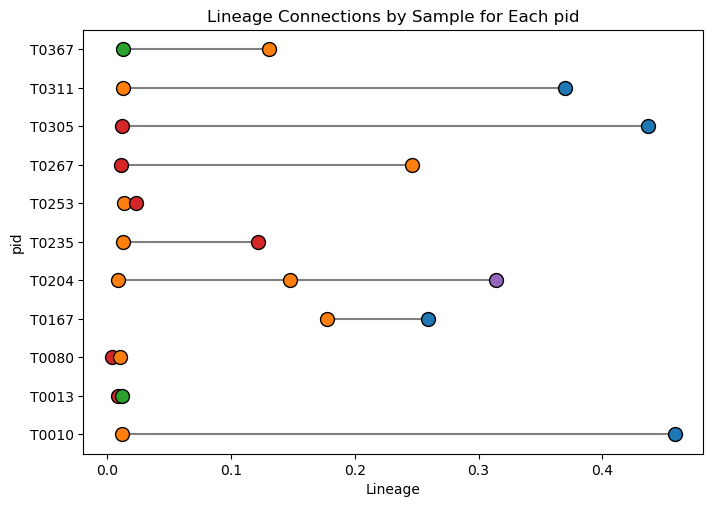

In [164]:
# Assuming df['Lineage'] contains your lineage values
unique_lineages = df_plot_lineage_diff_during_tx['Lineage'].unique()

# Use a colormap to generate colors
colors = plt.cm.tab10(range(len(unique_lineages)))  # You can replace `tab10` with other colormaps

# Create the color dictionary
color_dict = {lineage: color for lineage, color in zip(unique_lineages, colors)}


# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, len(df_plot_lineage_diff_during_tx['pid'].unique()) * 0.5))

# Iterate over each pid and plot lines between the two sample points
for pid in df_plot_lineage_diff_during_tx['pid'].unique():

    df_pid = df_plot_lineage_diff_during_tx.query("pid==@pid").sort_values(by='specimen_num')
    
    # Plot a line connecting the two F2 points for this pid
    ax.plot(
        df_pid['F2'],
        [pid] * len(df_pid),
        linestyle='-', 
        color='gray',  # Line color connecting the points (optional)
        zorder=1
    )
    
    # Plot each point individually with its color from Lineage
    for _, row in df_pid.iterrows():
        ax.scatter(
            row['F2'], 
            pid, 
            color=color_dict.get(row['Lineage'], 'gray'),  # Color based on Lineage
            s=100,  # Adjust point size if needed
            edgecolor='black',  # Optional: add border for visibility
            zorder=2
        )
        
        # # Optionally add annotations for SampleID at each point
        # ax.text(
        #     row['F2'],
        #     pid,
        #     f"{row['SampleID']}",
        #     ha='center',
        #     va='bottom',
        #     fontsize=9,
        #     color='black'
        # )

# Customize the plot
ax.set_yticks(df_plot_lineage_diff_during_tx['pid'].unique())  # Set y-axis to show each pid
ax.set_xlabel('Lineage')
ax.set_ylabel('pid')
plt.title("Lineage Connections by Sample for Each pid")
plt.legend()

# Display the plot
plt.show()

In [168]:
def plot_pid_lines_with_arrows(df, color_dict):
    fig, ax = plt.subplots(figsize=(8, len(df['pid'].unique()) * 0.5))

    for pid, group in df.groupby('pid'):

        group = group.sort_values(by='specimen_num')
        
        # Extract values for F2 and Lineage for plotting
        x_values = group['F2'].values
        y_value = pid  # This will be the same for both points
        lineages = group['Lineage'].values
        
        # Plot the points for each sample, coloring by Lineage
        ax.plot(x_values, [y_value]*len(x_values), color='gray', linestyle='-', linewidth=1, marker='o')
        
        # Plot each point with its lineage color
        for i, (x, lineage) in enumerate(zip(x_values, lineages)):
            ax.plot(x, y_value, 'o', color=color_dict[lineage], label=lineage if i == 0 else "")
        
        # Add an arrow from the first to the second point
        ax.annotate(
            '', xy=(x_values[1], y_value), xytext=(x_values[0], y_value),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
        )

    # Customize the plot appearance
    ax.set_yticks(df['pid'].unique())
    ax.set_yticklabels(df['pid'].unique())
    ax.set_xlabel('F2')
    ax.set_title('Patient Lineage Progression with Directional Arrows')
    plt.legend()

    plt.gca().invert_yaxis()  # Optional, to match typical plot conventions
    plt.show()

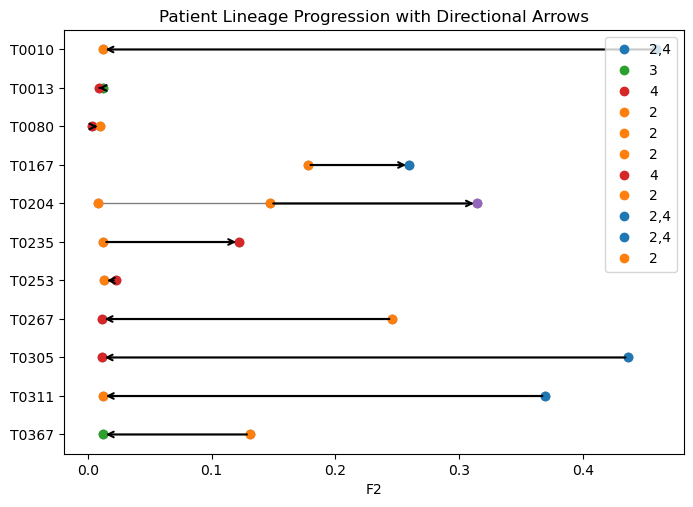

In [169]:
# Assuming `color_dict` is already created
plot_pid_lines_with_arrows(df_plot_lineage_diff_during_tx, color_dict)

## 2. Do re-enrolled patients have different or same lineages during their second (or third) infection?

In [102]:
df_WGS_metadata.query("pid=='T0272'")

,pid,SampleID,Original_ID,Kraken_Unclassified_Percent,Median_Depth,Prop_Sites_10x,Prop_Sites_20x,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,sample_num
211,T0272,MFS-279,S0272-09,0.62,330.0,0.984225,0.983802,0.009560,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,2,09
309,T0272,MFS-383,S0272-02,0.39,270.0,0.984104,0.983746,0.009333,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,2,02


In [97]:
df_WGS_metadata.query("pid=='T0263'")

,pid,SampleID,Original_ID,Kraken_Unclassified_Percent,Median_Depth,Prop_Sites_10x,Prop_Sites_20x,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,sample_num
206,T0263,MFS-274,S0263-01A,0.57,295.0,0.985309,0.984938,0.011353,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2,01A


In [98]:
df_WGS_metadata.query("pid=='T0271'")

,pid,SampleID,Original_ID,Kraken_Unclassified_Percent,Median_Depth,Prop_Sites_10x,Prop_Sites_20x,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,sample_num
200,T0271,MFS-268,S0271-05,0.48,291.0,0.985530,0.985193,0.012523,2.2.1.1,2.2.1.1.1,beijing,"lin2.2.1,pacific_RD150",NaN,2,05
208,T0271,MFS-276,S0271-01A,0.58,313.0,0.985776,0.985391,0.010859,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,2,01A


In [104]:
df_full[['pid', 'culture_conversion_sputum_specimen_15']].dropna().query("culture_conversion_sputum_specimen_15.str.contains('tb_positive')")

,pid,culture_conversion_sputum_specimen_15
237,T0252,tb_positive


In [103]:
df_full[['pid', 'culture_conversion_sputum_specimen_13']].dropna().query("culture_conversion_sputum_specimen_13.str.contains('tb_positive')")

,pid,culture_conversion_sputum_specimen_13
191,T0204,tb_positive
257,T0272,tb_positive
311,T0330,tb_positive


In [99]:
df_full.columns[df_full.columns.str.contains('culture_conversion')]

Index(['culture_conversion_sputum_specimen_1',
       'culture_conversion_sputum_specimen_10',
       'culture_conversion_sputum_specimen_11',
       'culture_conversion_sputum_specimen_12',
       'culture_conversion_sputum_specimen_13',
       'culture_conversion_sputum_specimen_14',
       'culture_conversion_sputum_specimen_15',
       'culture_conversion_sputum_specimen_16',
       'culture_conversion_sputum_specimen_17',
       'culture_conversion_sputum_specimen_18',
       'culture_conversion_sputum_specimen_2',
       'culture_conversion_sputum_specimen_3',
       'culture_conversion_sputum_specimen_4',
       'culture_conversion_sputum_specimen_5',
       'culture_conversion_sputum_specimen_6',
       'culture_conversion_sputum_specimen_7',
       'culture_conversion_sputum_specimen_8',
       'culture_conversion_sputum_specimen_9'],
      dtype='object')

In [88]:
samples_per_pid = pd.DataFrame(df_WGS_metadata.groupby("pid")['SampleID'].count()).reset_index()

In [90]:
samples_per_pid.query("SampleID > 1")

,pid,SampleID
1,T0002,2
2,T0003,2
3,T0004,2
4,T0005,2
6,T0008,2
...,...,...
318,T0389,2
321,T0392,2
322,T0393,2
323,T0394,2


In [52]:
df_trust_WGS_metadata.query("SampleID=='MFS-717'")

,SampleID,SampleLib,Original_ID,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,Excluded,repeat_pacbio,transfered_pcrfree,transfered_pacbio,repeat_pcrfree,shipment,status,comment,"phylogenetic classification (Coll et al., 2014)"
208,MFS-717,MFS-717_lib66590,S0456-01,NaN,NaN,1.0,218.63,0.99,0.9861,0.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [37]:
df_pid_with_lineage = df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Lineage', 'F2']].dropna(subset='Lineage').drop_duplicates(subset='pid')

for col in df_pid_with_lineage.columns:
    if col != 'pid':
        df_pid_with_lineage.rename(columns={col: f'pid_{col}'}, inplace=True)

df_screen_prevpid_with_lineage = df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Lineage', 'F2']].dropna(subset='Lineage').drop_duplicates(subset='pid')

for col in df_screen_prevpid_with_lineage.columns:
    if col != 'pid':
        df_screen_prevpid_with_lineage.rename(columns={col: f'screen_prevpid_{col}'}, inplace=True)
    else:
        df_screen_prevpid_with_lineage.rename(columns={col: 'screen_prevpid'}, inplace=True)

In [38]:
df_pid_with_lineage

,pid,pid_SampleID,pid_Coll2014,pid_Lineage,pid_F2
0,T0002,MFS-509,4.8,4.0,0.006467
2,T0003,MFS-511,2.2.1,2.0,0.009607
4,T0008,MFS-513,4.1.1.1,4.0,0.006976
6,T0011,MFS-514,2.2.1.1,2.0,0.010864
8,T0012,MFS-516,4.1.1.3,4.0,0.017793
...,...,...,...,...,...
622,T0290,MFS-264,2.2.1.1,2,0.013014
624,T0203,MFS-278,2.2.1,2,0.012411
625,T0312,MFS-290,3,3,0.013378
627,T0295,MFS-284,2.2.1.1,2,0.012322


In [39]:
df_screen_prevpid_with_lineage

,screen_prevpid,screen_prevpid_SampleID,screen_prevpid_Coll2014,screen_prevpid_Lineage,screen_prevpid_F2
0,T0002,MFS-509,4.8,4.0,0.006467
2,T0003,MFS-511,2.2.1,2.0,0.009607
4,T0008,MFS-513,4.1.1.1,4.0,0.006976
6,T0011,MFS-514,2.2.1.1,2.0,0.010864
8,T0012,MFS-516,4.1.1.3,4.0,0.017793
...,...,...,...,...,...
622,T0290,MFS-264,2.2.1.1,2,0.013014
624,T0203,MFS-278,2.2.1,2,0.012411
625,T0312,MFS-290,3,3,0.013378
627,T0295,MFS-284,2.2.1.1,2,0.012322


In [33]:
df_reenroll_with_dates.merge(df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Lineage', 'F2']].dropna(subset='Lineage').drop_duplicates(subset='pid'), how='left')

,pid,screen_prevpid,pid_screen_date,screen_prevpid_screen_date,screening_diff,SampleID,Coll2014,Lineage,F2
0,T0254,T0210,2021-02-05,2019-12-18,415.0,MFS-170,2.2.1.1,2,0.011597
1,T0267,T0066,2021-05-07,2018-05-07,1096.0,MFS-270,2.2.1.1,2,0.245979
2,T0275,T0194,2021-05-26,2019-09-25,609.0,NaN,NaN,NaN,NaN
3,T0279,T0103,2021-06-28,2018-09-11,1021.0,MFS-298,4.3.2.1,4,0.013741
4,T0281,T0032,2021-08-03,2017-11-22,1350.0,NaN,NaN,NaN,NaN
5,T0330,T0257,2022-02-17,2021-03-04,350.0,MFS-660,4.1.1.1,4,0.006470
6,T0336,T0249,2022-04-25,2021-01-05,475.0,MFS-407,2.2.1,2,0.009269
7,T0340,T0176,2022-06-08,2019-07-19,1055.0,MFS-415,2.2.1.1,2,0.011610
8,T0348,T0191,2022-07-04,2019-09-19,1019.0,NaN,NaN,NaN,NaN
9,T0363,T0130,2022-09-01,2018-12-11,1360.0,MFS-448,2.2.1.1,2,0.009318
